In [1]:
import torch
import torch.nn as nn
from torchvision import models
from torch.nn.functional import relu
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt

/home/gianluca/miniconda3/envs/computing_methods/lib/python3.9/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/gianluca/miniconda3/envs/computing_methods/lib/python3.9/site-packages/torchvision/image.so: undefined symbol: _ZNK3c107SymBool10guard_boolEPKcl'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# Dice loss

In [2]:
"""
def dice_loss(preds, targets):
  # sigmoid maps unbounded numbers to continous probability range [0,1]
  pred = torch.sigmoid(preds)
  intersection = (pred * targets).sum()
  dice = (2. * intersection + 1.0) / (preds.sum() + targets.sum() + 1.0)
  return 1 - dice
"""
def dice_loss(preds, targets, smooth=1e-6):
    """
    Dice = 2 x | A & B | / |A| + |B|
    
    :param preds: tensor of predictions (dims)
    :param targets: tensor of targets (dims)
    """
    # sigmoid maps unbounded numbers to continous probability range [0,1]
    sigmoid_preds = torch.sigmoid(preds)

    sigmoid_preds = sigmoid_preds.contiguous().view(-1)
    targets = targets.contiguous().view(-1)
    
    intersection = (sigmoid_preds * targets).sum()
    union = sigmoid_preds.sum() + targets.sum()
    dice = (2. * intersection + smooth) / (union + smooth)
    return 1.0 - dice

# Dataset

In [3]:
class TestDataset(Dataset):
    def __init__(self, train, transform=None):
        self.n_elements=4
        self.transform = transform

        if train:
          self.images = torch.rand((self.n_elements, 3, 572, 572))
          self.masks = torch.rand((self.n_elements, 2, 388, 388))
        else:
          self.images = torch.rand((4, 3, 572, 572))
          self.masks = torch.rand((4, 2, 388, 388))

    def __len__(self):
        return self.n_elements

    def __getitem__(self, idx):
        image = self.images[idx]

        if self.transform:
            image = self.transform(image)

        return image, self.masks[idx]

# Model

In [4]:
def center_crop(enc_feat, target_feat):
  """
  Crop encoder feature map to match target feature map size.
  """
  _, _, H, W = target_feat.shape
  _, _, H_enc, W_enc = enc_feat.shape

  delta_h = H_enc - H
  delta_w = W_enc - W

  top = delta_h // 2
  left = delta_w // 2

  return enc_feat[:, :, top:top + H, left:left + W]

class UNet(nn.Module):
  """
  For convolutional layer:
  Output size O of a single dimension: O = (I - K + 2P)/S + 1
  with I: input size, K: kernel size, P: padding, S: stride

  For pooling layer:
  Output size O of a single dimension: O = (I - K)/S + 1
  """
  def __init__(self, n_class):
    super().__init__()

    # encoder
    # input: 572x572x1
    self.e11 = nn.Conv2d(1, 64, kernel_size=3) # output: 570x570x64
    self.e12 = nn.Conv2d(64, 64, kernel_size=3) # output: 568x568x64
    self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 284x284x64

    # input: 284x284x64
    self.e21 = nn.Conv2d(64, 128, kernel_size=3) # output: 282x282x128
    self.e22 = nn.Conv2d(128, 128, kernel_size=3) # output: 280x280x128
    self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 140x140x128

    # input: 140x140x128
    self.e31 = nn.Conv2d(128, 256, kernel_size=3) # output: 138x138x256
    self.e32 = nn.Conv2d(256, 256, kernel_size=3) # output: 136x136x256
    self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 68x68x256

    # input: 68x68x256
    self.e41 = nn.Conv2d(256, 512, kernel_size=3) # output: 66x66x512
    self.e42 = nn.Conv2d(512, 512, kernel_size=3) # output: 64x64x512
    self.pool4 = nn.MaxPool2d(kernel_size=2, stride=2) # output: 32x32x512

    # input: 32x32x512
    self.e51 = nn.Conv2d(512, 1024, kernel_size=3) # output: 30x30x1024
    self.e52 = nn.Conv2d(1024, 1024, kernel_size=3) # output: 28x28x1024

    # Decoder
    # input: 28x28x1024
    self.upconv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2) # output: 56x56x512
    # here a copy of the feature map is copied from the encoder, size becomes 56x56x1024
    self.d11 = nn.Conv2d(1024, 512, kernel_size=3) # output: 54x54x512
    self.d12 = nn.Conv2d(512, 512, kernel_size=3) # output: 52x52x512

    self.upconv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2) # output: 104x104x256
    # concatenation of feature maps, new size: 104x104x512
    self.d21 = nn.Conv2d(512, 256, kernel_size=3) # output: 102x102x256
    self.d22 = nn.Conv2d(256, 256, kernel_size=3) # output: 100x100x256

    self.upconv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) # output: 200x200x128
    # concatenation of feature maps, new size: 200x200x256
    self.d31 = nn.Conv2d(256, 128, kernel_size=3) # output: 198x198x128
    self.d32 = nn.Conv2d(128, 128, kernel_size=3) # output: 196x196x128

    self.upconv4 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # output: 392x392x64
    # concatenation of feature maps, new size: 392x392x128
    self.d41 = nn.Conv2d(128, 64, kernel_size=3) # output: 390x390x64
    self.d42 = nn.Conv2d(64, 64, kernel_size=3) # output: 388x388x64

    # Output layer
    self.outconv = nn.Conv2d(64, n_class, kernel_size=1) # output: 388x388x2

  def forward(self, x):
    # Encoder
    xe11 = relu(self.e11(x))
    xe12 = relu(self.e12(xe11))
    xp1 = self.pool1(xe12)

    xe21 = relu(self.e21(xp1))
    xe22 = relu(self.e22(xe21))
    xp2 = self.pool2(xe22)

    xe31 = relu(self.e31(xp2))
    xe32 = relu(self.e32(xe31))
    xp3 = self.pool3(xe32)

    xe41 = relu(self.e41(xp3))
    xe42 = relu(self.e42(xe41))
    xp4 = self.pool4(xe42)

    xe51 = relu(self.e51(xp4))
    xe52 = relu(self.e52(xe51))

    # Decoder
    xu1 = self.upconv1(xe52)
    xu11 = torch.cat([center_crop(xe42, xu1), xu1], dim=1) # center cropping and concatenation of feature maps
    xd11 = relu(self.d11(xu11))
    xd12 = relu(self.d12(xd11))

    xu2 = self.upconv2(xd12)
    xu22 = torch.cat([center_crop(xe32, xu2), xu2], dim=1)
    xd21 = relu(self.d21(xu22))
    xd22 = relu(self.d22(xd21))

    xu3 = self.upconv3(xd22)
    xu33 = torch.cat([center_crop(xe22, xu3), xu3], dim=1)
    xd31 = relu(self.d31(xu33))
    xd32 = relu(self.d32(xd31))

    xu4 = self.upconv4(xd32)
    xu44 = torch.cat([center_crop(xe12, xu4), xu4], dim=1)
    xd41 = relu(self.d41(xu44))
    xd42 = relu(self.d42(xd41))

    # Output layer
    out = self.outconv(xd42)

    return out

# Interactive part

In [7]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)

    model.train() # set the model to training mode
    for batch, (X,y) in enumerate(dataloader):
        # compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # backpropagation
        loss.backward() # backpropagate the prediction loss
        optimizer.step() # adjust the parameters by the gradients collected in the backward pass
        optimizer.zero_grad() # reset the gradients of model parameters

        loss, current = loss.item(), batch * batch_size + len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

def test_loop(dataloader, model, loss_fn):
  model.eval() # set model to evaluation mode
  size = len(dataloader.dataset)
  num_batches = len(dataloader)
  test_loss = 0

  with torch.no_grad():
    for X, y in dataloader:
      pred = model(X)
      test_loss += loss_fn(pred, y).item()

  test_loss /= num_batches
  print(f"Test Error: \n Avg loss: {test_loss:>8f} \n")

In [8]:
learning_rate = 1e-3
batch_size = 2
epochs = 1

# loading data
train_data = TestDataset(train=True)
test_data = TestDataset(train=False)
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# defyning loss function
loss_fn = dice_loss

model = UNet(n_class=2)

# defyning optimizer
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=learning_rate
)

# training loop
for t in range(epochs):
    print(f"Epoch {t+1}\n------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)

Epoch 1
------------
loss: 0.076454  [    2/    4]
loss: 0.075459  [    4/    4]
Test Error: 
 Avg loss: 0.074414 



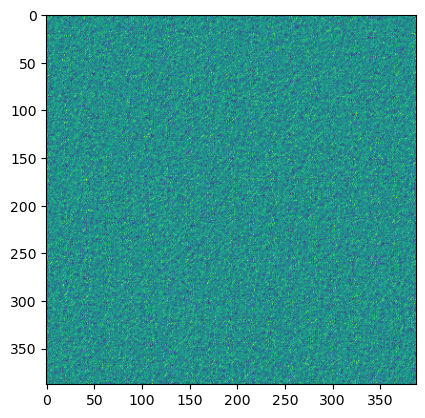

In [ ]:
plt.imshow(output[0].permute(1,2,0).detach().numpy()[:,:,0])